In [1]:
!pip install -q iterative-stratification
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

from torchmetrics import MeanMetric
from torchmetrics.classification import MultilabelF1Score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Load data from folder

[1. 0. 0. 0. 0. 0. 0. 0.]


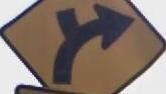

In [2]:
data_path = "/kaggle/input/datasets/phnggiakhang/damaged-signs-multilabel/train"

classes = ["bent", "broken_sheet", "crack", "graffiti",
    "normal", "paint_loss", "rust", "scratch"]

# Load the CSV file
csv_path = os.path.join(data_path, "_classes.csv")
df = pd.read_csv(csv_path)

image_paths = [
    os.path.join(data_path, fname)
    for fname in df['filename']
]
image_paths = np.array(image_paths)
labels = df.drop(columns=['filename']).to_numpy(dtype=np.float32)

# Test opening the first image
test_image = Image.open(image_paths[0]).convert("RGB")
print(labels[0])
display(test_image)

### Create a custom dataset class

In [3]:
class MultiLabelDataset(Dataset):
    def __init__(self, image_paths, labels, transforms=None):
        self.image_paths = image_paths
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.transforms = transforms
    
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")

        # Data augmentation
        if self.transforms:
            image = self.transforms(image)
        
        return image, self.labels[idx]

### Train-test split

In [4]:
# Train/Test split
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

for train_idx, temp_idx in msss.split(image_paths, labels):
    train_paths = image_paths[train_idx]
    temp_paths = image_paths[temp_idx]

    train_labels = labels[train_idx]
    temp_labels = labels[temp_idx]

In [5]:
# Train/Val split
msss_val = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

for val_idx, test_idx in msss_val.split(temp_paths, temp_labels):
    val_paths = temp_paths[val_idx]
    test_paths = temp_paths[test_idx]

    val_labels = temp_labels[val_idx]
    test_labels = temp_labels[test_idx]

In [6]:
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 1329
Validation: 272
Test: 285


### Data augmentation

In [7]:
# Mean and Std from ImageNet1K
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

### Create datasets and data loaders

In [8]:
train_dataset = MultiLabelDataset(train_paths, train_labels, transforms=train_transforms)
val_dataset = MultiLabelDataset(val_paths, val_labels, transforms=val_transforms)
test_dataset = MultiLabelDataset(test_paths, test_labels, transforms=test_transforms)

In [9]:
# Data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2

)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

### Load the EfficientNetV2 model fine-tuned on damaged signs

In [10]:
num_classes = len(train_labels[0])

model = efficientnet_v2_s(weights=None)

# match your custom classifier
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),

    nn.Dropout(p=0.3),
    nn.Linear(512, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(inplace=True),

    nn.Linear(128, num_classes)
)

checkpoint_path = "/kaggle/input/models/phnggiakhang/fine-tuned-effnetv2/pytorch/default/1/EffnetV2_fine-tuned.pth"

state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)

# Freeze the base for transfer learning
for param in model.features.parameters():
    param.requires_grad = False

### Multi-class => Multi-label

In [11]:
# Compute pos_weight for handling data imbalance
all_labels = torch.tensor(labels).float()

pos_counts = all_labels.sum(dim=0)
neg_counts = all_labels.size(0) - pos_counts

pos_weight = neg_counts / (pos_counts + 1e-6)
pos_weight = pos_weight.to(device)

In [12]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',        
    factor=0.4,     
    patience=3,
)

In [13]:
# Early stopping config
early_stop_patience = 7
best_val_f1 = 0
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

num_epochs = 70

In [14]:
# Record training history for plotting
history = {
    "train_loss":[],
    "val_loss":[],
    "train_f1":[],
    "val_f1":[]
}

for epoch in range(num_epochs):
    model.train()
    mean_train_loss = MeanMetric().to(device)
    mean_train_f1 = MultilabelF1Score(num_labels=num_classes, average="macro", threshold=0.4).to(device)

    # Training step
    for images, batch_labels in train_loader:
        images = images.to(device)
        batch_labels = batch_labels.to(device).float()
        
        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, batch_labels)

        # Back propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update f1 and loss
        mean_train_loss.update(loss, weight=images.shape[0])
        mean_train_f1.update(outputs, batch_labels)

    # Validation
    model.eval()
    mean_val_loss = MeanMetric().to(device)
    mean_val_f1 = MultilabelF1Score(num_labels=num_classes, average="macro", threshold=0.4).to(device)
    
    with torch.no_grad():
        for images, batch_labels in val_loader:
            images = images.to(device)
            batch_labels = batch_labels.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, batch_labels)

            mean_val_loss.update(loss, weight=images.shape[0])
            mean_val_f1.update(outputs, batch_labels)

    # Get the metric values
    train_loss = mean_train_loss.compute().item()
    val_loss = mean_val_loss.compute().item()
    train_f1 = mean_train_f1.compute().item()
    val_f1 = mean_val_f1.compute().item()

    # Save to history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    # Update the learning rate (ReduceLROnPlateau)
    scheduler.step(val_f1)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "EffnetV2_multilabel.pth")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch+1}: Train F1={train_f1:.4f}, Val F1={val_f1:.4f}, Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if epochs_no_improve >= early_stop_patience:
        print("Early stopping triggered")
        break

print("Model saved to /kaggle/working/EffnetV2_multilabel.pth")

Epoch 1: Train F1=0.4092, Val F1=0.5040, Train Loss=0.7651, Val Loss=0.6541
Epoch 2: Train F1=0.4501, Val F1=0.5518, Train Loss=0.6767, Val Loss=0.5925
Epoch 3: Train F1=0.4847, Val F1=0.5921, Train Loss=0.6196, Val Loss=0.5597
Epoch 4: Train F1=0.5038, Val F1=0.6273, Train Loss=0.5899, Val Loss=0.5231
Epoch 5: Train F1=0.5277, Val F1=0.6385, Train Loss=0.5575, Val Loss=0.4990
Epoch 6: Train F1=0.5558, Val F1=0.6788, Train Loss=0.5348, Val Loss=0.4716
Epoch 7: Train F1=0.5694, Val F1=0.6974, Train Loss=0.5117, Val Loss=0.4565
Epoch 8: Train F1=0.5843, Val F1=0.7092, Train Loss=0.5071, Val Loss=0.4283
Epoch 9: Train F1=0.6042, Val F1=0.7137, Train Loss=0.4733, Val Loss=0.4241
Epoch 10: Train F1=0.6071, Val F1=0.7197, Train Loss=0.4753, Val Loss=0.4185
Epoch 11: Train F1=0.6209, Val F1=0.7522, Train Loss=0.4582, Val Loss=0.3912
Epoch 12: Train F1=0.6365, Val F1=0.7535, Train Loss=0.4354, Val Loss=0.3855
Epoch 13: Train F1=0.6487, Val F1=0.7561, Train Loss=0.4262, Val Loss=0.3673
Epoch 14

### Fine-tuning

In [15]:
# Freeze everything first
for p in model.features.parameters():
    p.requires_grad = False

# Unfreeze last block (stage -1)
for p in model.features[-1].parameters():
    p.requires_grad = True

In [16]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-5,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',        
    factor=0.4,     
    patience=3,
)

In [17]:
# Early stopping config
early_stop_patience = 10
best_val_f1 = 0
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

num_epochs = 30

In [18]:
# Fine-tuning loop
for epoch in range(num_epochs):
    model.train()
    mean_train_loss = MeanMetric().to(device)
    mean_train_f1 = MultilabelF1Score(num_labels=num_classes, average="macro", threshold=0.4).to(device)

    # Training step
    for images, batch_labels in train_loader:
        images = images.to(device)
        batch_labels = batch_labels.to(device).float()
        
        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, batch_labels)

        # Back propagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update f1 and loss
        mean_train_loss.update(loss, weight=images.shape[0])
        mean_train_f1.update(outputs, batch_labels)

    # Validation
    model.eval()
    mean_val_loss = MeanMetric().to(device)
    mean_val_f1 = MultilabelF1Score(num_labels=num_classes, average="macro", threshold=0.4).to(device)
    
    with torch.no_grad():
        for images, batch_labels in val_loader:
            images = images.to(device)
            batch_labels = batch_labels.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, batch_labels)

            mean_val_loss.update(loss, weight=images.shape[0])
            mean_val_f1.update(outputs, batch_labels)

    # Get the metric values
    train_loss = mean_train_loss.compute().item()
    val_loss = mean_val_loss.compute().item()
    train_f1 = mean_train_f1.compute().item()
    val_f1 = mean_val_f1.compute().item()

    # Save to history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    # Update the learning rate (ReduceLROnPlateau)
    scheduler.step(val_f1)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "EffnetV2_multilabel.pth")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch+1}: Train F1={train_f1:.4f}, Val F1={val_f1:.4f}, Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if epochs_no_improve >= early_stop_patience:
        print("Early stopping triggered")
        break

print("Model saved to /kaggle/working/EffnetV2_multilabel_finetuned.pth")

Epoch 1: Train F1=0.7425, Val F1=0.8331, Train Loss=0.3113, Val Loss=0.2818
Epoch 2: Train F1=0.7386, Val F1=0.8249, Train Loss=0.3149, Val Loss=0.2797
Epoch 3: Train F1=0.7415, Val F1=0.8343, Train Loss=0.3199, Val Loss=0.2800
Epoch 4: Train F1=0.7425, Val F1=0.8340, Train Loss=0.3151, Val Loss=0.2769
Epoch 5: Train F1=0.7409, Val F1=0.8435, Train Loss=0.3226, Val Loss=0.2847
Epoch 6: Train F1=0.7508, Val F1=0.8292, Train Loss=0.3086, Val Loss=0.2789
Epoch 7: Train F1=0.7444, Val F1=0.8275, Train Loss=0.3139, Val Loss=0.2814
Epoch 8: Train F1=0.7474, Val F1=0.8413, Train Loss=0.3160, Val Loss=0.2847
Epoch 9: Train F1=0.7515, Val F1=0.8204, Train Loss=0.3033, Val Loss=0.2758
Epoch 10: Train F1=0.7511, Val F1=0.8230, Train Loss=0.3124, Val Loss=0.2826
Epoch 11: Train F1=0.7408, Val F1=0.8390, Train Loss=0.3220, Val Loss=0.2790
Epoch 12: Train F1=0.7511, Val F1=0.8310, Train Loss=0.3107, Val Loss=0.2881
Epoch 13: Train F1=0.7451, Val F1=0.8234, Train Loss=0.3138, Val Loss=0.2841
Epoch 14

### Plot training history

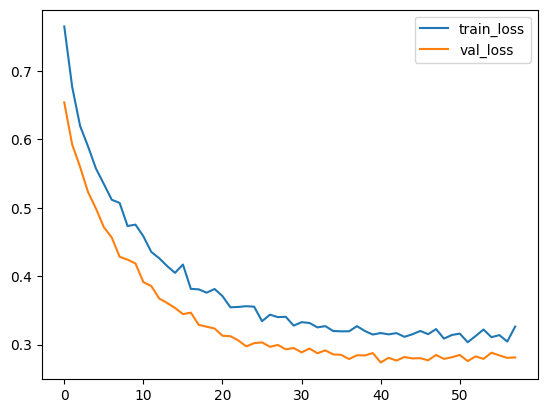

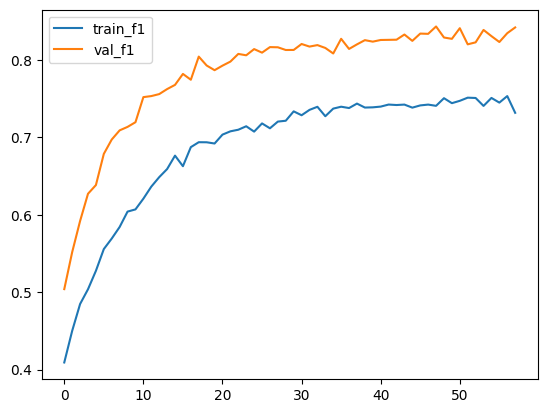

In [19]:
# Loss the training loss and accuracy
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()

plt.figure()
plt.plot(history["train_f1"], label="train_f1")
plt.plot(history["val_f1"], label="val_f1")
plt.legend()

### Threshold calibration 

In [20]:
# Load the fine-tuned model
def load_effnetv2_multilabel(model_path, num_classes=8, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')):
    # Rebuild the architecture
    model = efficientnet_v2_s(weights=None)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),

        nn.Dropout(p=0.3),
        nn.Linear(512, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),

        nn.Linear(128, num_classes)
    )

    # Load weights
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)

    model = model.to(device)
    model.eval()

    return model

model = load_effnetv2_multilabel(model_path='/kaggle/input/models/phnggiakhang/effnetv2-multilabel/pytorch/default/1/EffnetV2_multilabel.pth')

In [21]:
# Get the predictions of the model
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

all_probs = torch.cat(all_probs).numpy()   # [N, C]
all_labels = torch.cat(all_labels).numpy() # [N, C]

In [22]:
# Collect per class validations
import numpy as np
from sklearn.metrics import f1_score

num_classes = all_labels.shape[1]
best_thresholds = np.zeros(num_classes)
best_f1_scores = np.zeros(num_classes)

threshold_candidates = np.linspace(0.1, 0.9, 17)  # step = 0.05

for i in range(num_classes):
    y_true = all_labels[:, i]
    y_prob = all_probs[:, i]

    best_f1 = 0
    best_t = 0.5

    for t in threshold_candidates:
        y_pred = (y_prob > t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds[i] = best_t
    best_f1_scores[i] = best_f1

In [23]:
class_names = [
    "bent", "broken_sheet", "crack", "graffiti",
    "normal", "paint_loss", "rust", "scratch"
]

for i, cls in enumerate(class_names):
    print(f"{cls}: best_threshold={best_thresholds[i]:.2f}, best_f1={best_f1_scores[i]:.4f}")

print(best_thresholds)

bent: best_threshold=0.80, best_f1=0.9333
broken_sheet: best_threshold=0.85, best_f1=0.9809
crack: best_threshold=0.80, best_f1=0.9436
graffiti: best_threshold=0.45, best_f1=0.9645
normal: best_threshold=0.75, best_f1=0.9173
paint_loss: best_threshold=0.70, best_f1=0.9013
rust: best_threshold=0.70, best_f1=0.9008
scratch: best_threshold=0.85, best_f1=0.9652
[0.8  0.85 0.8  0.45 0.75 0.7  0.7  0.85]


### Evaluation

In [24]:
from sklearn.metrics import classification_report, f1_score, jaccard_score, average_precision_score
# Get the predictions on the test set
model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        thresholds_tensor = torch.tensor(best_thresholds).to(probs.device)
        
        preds = (probs > thresholds_tensor).int()
        
        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_probs = torch.cat(all_probs).numpy()
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

In [25]:
# Macro F1, Weighted F1 and mAP
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print("Macro F1:", macro_f1)

weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
print("Weighted F1:", weighted_f1)

# per-class AP then average
mAP = average_precision_score(all_labels, all_probs, average='macro')
print("mAP (macro):", mAP)

Macro F1: 0.8999038465248281
Weighted F1: 0.9088250537731651
mAP (macro): 0.963360775166835


In [26]:
# Overall IoU
jaccard = jaccard_score(all_labels, all_preds, average='macro')
print("Jaccard (IoU):", jaccard)

# Per-class IoU
jaccard_per_class = jaccard_score(all_labels, all_preds, average=None)

for i, cls in enumerate(classes):
    print(f"{cls}: IoU = {jaccard_per_class[i]:.4f}")

Jaccard (IoU): 0.8223944071031449
bent: IoU = 0.6667
broken_sheet: IoU = 0.8889
crack: IoU = 0.8333
graffiti: IoU = 0.9359
normal: IoU = 0.8544
paint_loss: IoU = 0.7000
rust: IoU = 0.8154
scratch: IoU = 0.8846


In [27]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
)

print("\n--- Classification Report ---")
print(report)


--- Classification Report ---
              precision    recall  f1-score   support

        bent       0.96      0.68      0.80        38
broken_sheet       0.94      0.94      0.94        17
       crack       0.87      0.95      0.91        21
    graffiti       0.97      0.96      0.97        76
      normal       0.88      0.97      0.92        91
  paint_loss       0.81      0.84      0.82        25
        rust       0.87      0.93      0.90        57
     scratch       0.96      0.92      0.94        25

   micro avg       0.91      0.91      0.91       350
   macro avg       0.91      0.90      0.90       350
weighted avg       0.91      0.91      0.91       350
 samples avg       0.91      0.92      0.91       350



### Stand-alone running script

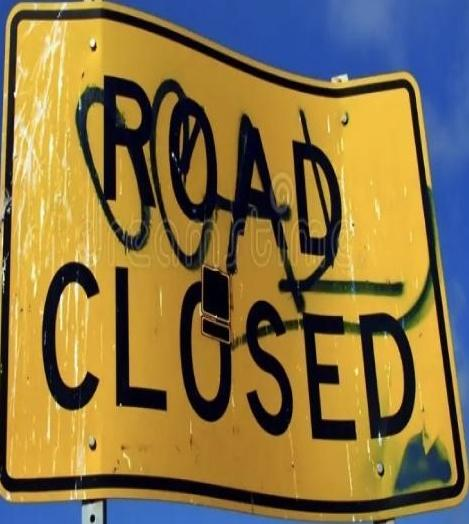

bent: 0.9901
graffiti: 0.8296
scratch: 0.9600


In [30]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import efficientnet_v2_s
from PIL import Image

def load_effnetv2_multilabel(model_path, num_classes=8, device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')):
    # Rebuild the architecture
    model = efficientnet_v2_s(weights=None)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),

        nn.Dropout(p=0.3),
        nn.Linear(512, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),

        nn.Linear(128, num_classes)
    )

    # Load weights
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)

    model = model.to(device)
    model.eval()

    return model
    

def predict_multilabel(image_path, model, device, thresholds=[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], class_names=None):

    # Transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Load image
    image = Image.open(image_path).convert("RGB")
    display(image)
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.sigmoid(outputs).squeeze(0)
        thresholds_tensor = torch.tensor(thresholds).to(probs.device)

    preds = (probs > thresholds_tensor).int()

    # Mapping to class_names
    if class_names is not None:
        results = [
            (class_names[i], probs[i].item())
            for i in range(len(class_names)) if preds[i] == 1
        ]
        return preds.cpu(), probs.cpu(), results

    return preds.cpu(), probs.cpu()


if __name__ == "__main__":
    model = load_effnetv2_multilabel(model_path='/kaggle/input/models/phnggiakhang/effnetv2-multilabel/pytorch/default/1/EffnetV2_multilabel.pth')
    thresholds = [0.8, 0.85, 0.8, 0.45, 0.75, 0.7, 0.7, 0.85]
    
    preds, probs, results = predict_multilabel(
        image_path=image_paths[1],
        model=model,
        device=device,
        thresholds=thresholds,
        class_names=class_names
    )
    
    for cls, prob in results:
        print(f"{cls}: {prob:.4f}")